In [72]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,random_split
from torch.optim import Adam
import torchvision.models as models
import cv2
import pyclipper
from shapely.geometry import Polygon

In [73]:
def denormalize(img_tensor):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = img * std + mean
    img = np.clip(img, 0, 1)

    return img


def show_random_sample(dataset, is_train=True, dbnet=False):

    idx = random.randint(0, len(dataset) - 1)

    if is_train:

        if dbnet:

            img, prob_map, thresh_map, training_mask = dataset[idx]

            img_vis = denormalize(img)

            fig, axes = plt.subplots(1, 4, figsize=(20, 5))

            axes[0].imshow(img_vis)
            axes[0].set_title(f"Train Image #{idx}")
            axes[0].axis("off")

            axes[1].imshow(prob_map.numpy(), cmap="gray")
            axes[1].set_title("Probability Map")
            axes[1].axis("off")

            axes[2].imshow(thresh_map.numpy(), cmap="jet")
            axes[2].set_title("Threshold Map")
            axes[2].axis("off")

            axes[3].imshow(training_mask.numpy(), cmap="gray")
            axes[3].set_title("Training Mask")
            axes[3].axis("off")

            plt.tight_layout()
            plt.show()

            print("Image:", img.shape)
            print("Probability Map:", prob_map.shape)
            print("Threshold Map:", thresh_map.shape)
            print("Training Mask:", training_mask.shape)

        else:

            img, gt_text, gt_kernels, training_mask = dataset[idx]

            img_vis = denormalize(img)

            fig, axes = plt.subplots(1, 4, figsize=(20, 5))

            axes[0].imshow(img_vis)
            axes[0].set_title(f"Train Image #{idx}")
            axes[0].axis("off")

            axes[1].imshow(gt_text.numpy(), cmap="gray")
            axes[1].set_title("GT Text")
            axes[1].axis("off")

            axes[2].imshow(gt_kernels[0].numpy(), cmap="gray")
            axes[2].set_title("Kernel 1")
            axes[2].axis("off")

            axes[3].imshow(training_mask.numpy(), cmap="gray")
            axes[3].set_title("Training Mask")
            axes[3].axis("off")

            plt.tight_layout()
            plt.show()

            print("Image:", img.shape)
            print("GT Text:", gt_text.shape)
            print("GT Kernels:", gt_kernels.shape)
            print("Training Mask:", training_mask.shape)

    else:

        original_img, scaled_img = dataset[idx]

        scaled_vis = denormalize(scaled_img)

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        axes[0].imshow(original_img)
        axes[0].set_title(
            f"Original #{idx}\n{original_img.shape[1]}x{original_img.shape[0]}"
        )
        axes[0].axis("off")

        axes[1].imshow(scaled_vis)
        axes[1].set_title(
            f"Scaled\n{scaled_vis.shape[1]}x{scaled_vis.shape[0]}"
        )
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

        print("Original:", original_img.shape)
        print("Scaled Tensor:", scaled_img.shape)

In [74]:
class DBPostProcess:
    def __init__(self, prob_threshold=0.3, unclip_ratio=1.5, min_area=16):
        """
        prob_threshold: The threshold to binarize the probability map.
        unclip_ratio: How much to expand the detected box (inverse of shrink_ratio).
        min_area: Ignore boxes smaller than this many pixels.
        """
        self.prob_threshold = prob_threshold
        self.unclip_ratio = unclip_ratio
        self.min_area = min_area

    def __call__(self, prob_map, orig_shape, target_shape):
        """
        prob_map: Tensor of shape (1, H, W) directly from the model output.
        orig_shape: (H, W) of the original unscaled image.
        target_shape: (H, W) of the image size passed to the network.
        """
        # 1. Binarize the probability map
        prob_map = prob_map.squeeze().cpu().numpy()
        segmentation = prob_map > self.prob_threshold
        
        # 2. Find contours of the text blobs
        mask = (segmentation * 255).astype(np.uint8)
        contours, _ = cv2.findContours(mask, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
        
        boxes = []
        for contour in contours:
            # 3. Fit a bounding polygon and check minimum area
            poly = cv2.approxPolyDP(contour, epsilon=0.005 * cv2.arcLength(contour, True), closed=True)
            if len(poly) < 4:
                rect = cv2.minAreaRect(contour)
                poly = cv2.boxPoints(rect)
            else:
                poly = poly.reshape(-1, 2)
                
            polygon_shape = Polygon(poly)
            if polygon_shape.area < self.min_area:
                continue
                
            # 4. Unclip (Expand) the polygon to its true boundary size
            distance = polygon_shape.area * self.unclip_ratio / (polygon_shape.length + 1e-5)
            offset = pyclipper.PyclipperOffset()
            offset.AddPath(poly.astype(np.int32), pyclipper.JT_ROUND, pyclipper.ET_CLOSEDPOLYGON)
            expanded = offset.Execute(distance)
            
            if len(expanded) == 0:
                continue
            
            # Get the exact 4-point bounding box of the expanded area
            expanded_poly = np.array(expanded[0])
            rect = cv2.minAreaRect(expanded_poly)
            box = cv2.boxPoints(rect)
            
            # 5. Scale coordinates back to the original image dimensions
            scale_x = orig_shape[1] / target_shape[1]
            scale_y = orig_shape[0] / target_shape[0]
            
            box[:, 0] = np.clip(box[:, 0] * scale_x, 0, orig_shape[1] - 1)
            box[:, 1] = np.clip(box[:, 1] * scale_y, 0, orig_shape[0] - 1)
            
            # Order the points strictly: Top-Left, Top-Right, Bottom-Right, Bottom-Left
            box = self.order_points_clockwise(box)
            boxes.append(box.astype(np.int32))
            
        return boxes

    def order_points_clockwise(self, pts):
        """Sorts the 4 points in a consistent Top-Left to Bottom-Left order."""
        rect = np.zeros((4, 2), dtype=np.float32)
        s = pts.sum(axis=1)
        rect[0] = pts[np.argmin(s)]
        rect[2] = pts[np.argmax(s)]
        diff = np.diff(pts, axis=1)
        rect[1] = pts[np.argmin(diff)]
        rect[3] = pts[np.argmax(diff)]
        return rect






class DifferentiableBinarization(nn.Module):
    def __init__(self, k=50):
        super().__init__()
        self.k = k

    def forward(self, prob_map, thresh_map):
        return torch.reciprocal(1.0 + torch.exp(-self.k * (prob_map - thresh_map)))



class ResNet18Backbone(nn.Module):
    def __init__(self, pretrained=False):
        super().__init__()

        if pretrained:
            resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        else:
            resnet = models.resnet18(weights=None)
            
       
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        
        self.layer1 = resnet.layer1  # Output: 1/4 resolution, 64 channels
        self.layer2 = resnet.layer2  # Output: 1/8 resolution, 128 channels
        self.layer3 = resnet.layer3  # Output: 1/16 resolution, 256 channels
        self.layer4 = resnet.layer4  # Output: 1/32 resolution, 512 channels

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        
        c2 = self.layer1(x)
        c3 = self.layer2(c2)
        c4 = self.layer3(c3)
        c5 = self.layer4(c4)
        
        return c2, c3, c4, c5



class DBNetFPN(nn.Module):
    def __init__(self, in_channels=[64, 128, 256, 512], inner_channels=256):
        super().__init__()
        
        self.reduce_c5 = nn.Conv2d(in_channels[3], inner_channels, kernel_size=1, bias=False)
        self.reduce_c4 = nn.Conv2d(in_channels[2], inner_channels, kernel_size=1, bias=False)
        self.reduce_c3 = nn.Conv2d(in_channels[1], inner_channels, kernel_size=1, bias=False)
        self.reduce_c2 = nn.Conv2d(in_channels[0], inner_channels, kernel_size=1, bias=False)
        
        self.smooth_p4 = nn.Conv2d(inner_channels, inner_channels // 4, kernel_size=3, padding=1, bias=False)
        self.smooth_p3 = nn.Conv2d(inner_channels, inner_channels // 4, kernel_size=3, padding=1, bias=False)
        self.smooth_p2 = nn.Conv2d(inner_channels, inner_channels // 4, kernel_size=3, padding=1, bias=False)
        self.smooth_p5 = nn.Conv2d(inner_channels, inner_channels // 4, kernel_size=3, padding=1, bias=False)

    def forward(self, features):
        c2, c3, c4, c5 = features
        
        p5 = self.reduce_c5(c5)
        
        # FIX 1: Explicitly target the spatial sizes of the C-layers instead of using scale_factor=2
        p4 = self.reduce_c4(c4) + F.interpolate(p5, size=c4.shape[2:], mode='nearest')
        p3 = self.reduce_c3(c3) + F.interpolate(p4, size=c3.shape[2:], mode='nearest')
        p2 = self.reduce_c2(c2) + F.interpolate(p3, size=c2.shape[2:], mode='nearest')
        
        # FIX 2: Explicitly upsample all maps to the exact spatial resolution of P2
        target_size = p2.shape[2:]
        
        p5_up = F.interpolate(self.smooth_p5(p5), size=target_size, mode='nearest')
        p4_up = F.interpolate(self.smooth_p4(p4), size=target_size, mode='nearest')
        p3_up = F.interpolate(self.smooth_p3(p3), size=target_size, mode='nearest')
        p2_up = self.smooth_p2(p2)
        
        fused_features = torch.cat([p2_up, p3_up, p4_up, p5_up], dim=1)
        return fused_features


# ---------------------------------------------------------
# 4. Head: Binarization Maps Estimator
# ---------------------------------------------------------
class DBHead(nn.Module):
    def __init__(self, in_channels=256, k=50):
        super().__init__()
        self.k = k
        
        # Probability Map Network
        self.prob_conv = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 4, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_channels // 4),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(in_channels // 4, in_channels // 4, kernel_size=2, stride=2),
            nn.BatchNorm2d(in_channels // 4),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(in_channels // 4, 1, kernel_size=2, stride=2),
            nn.Sigmoid()
        )
        
        # Threshold Map Network
        self.thresh_conv = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 4, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_channels // 4),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(in_channels // 4, in_channels // 4, kernel_size=2, stride=2),
            nn.BatchNorm2d(in_channels // 4),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(in_channels // 4, 1, kernel_size=2, stride=2),
            nn.Sigmoid()
        )
        
        self.binarize = DifferentiableBinarization(k=self.k)

    def forward(self, x):
        prob_map = self.prob_conv(x)
        thresh_map = self.thresh_conv(x)
        
        # Always generate the binarized map so we can compute validation loss
        binary_map = self.binarize(prob_map, thresh_map)
        
        return {
            'prob_map': prob_map, 
            'thresh_map': thresh_map, 
            'binary_map': binary_map
        }


# ---------------------------------------------------------
# 5. Complete Framework Assembly
# ---------------------------------------------------------
class DBNet(nn.Module):
    def __init__(self, pretrained_backbone=False, k=50):
        super().__init__()
        self.backbone = ResNet18Backbone(pretrained=pretrained_backbone)
        self.neck = DBNetFPN()
        self.head = DBHead(in_channels=256, k=k)

    def forward(self, x):
        # 1. Feature extraction
        features = self.backbone(x)
        # 2. Pyramid merging
        fused = self.neck(features)
        # 3. Text Map Generation
        out = self.head(fused)
        return out




# --- 1. The Tripartite Loss Function ---
class DBLoss(nn.Module):
    def __init__(self, alpha=1.0, beta=10.0):
        super().__init__()
        self.alpha = alpha
        self.beta = beta

    def forward(self, preds, labels):
        prob_map = preds['prob_map']
        thresh_map = preds['thresh_map']
        binary_map = preds['binary_map']

        gt_prob = labels['gt_prob']
        gt_thresh = labels['gt_thresh']
        thresh_mask = labels['thresh_mask']
        training_mask = labels['training_mask'] 

        # 1. L_s: Masked Binary Cross Entropy
        bce_loss = F.binary_cross_entropy(prob_map, gt_prob, reduction='none')
        bce_loss = bce_loss * training_mask
        l_s = bce_loss.sum() / (training_mask.sum() + 1e-5)

        # 2. L_b: Binary Map Loss (Dice Loss)
        intersection = torch.sum(binary_map * gt_prob * training_mask)
        union = torch.sum(binary_map * training_mask) + torch.sum(gt_prob * training_mask) + 1e-5
        l_b = 1.0 - (2.0 * intersection / union)

        # 3. L_t: Threshold Map Loss (Masked L1 Loss)
        l_t = F.l1_loss(thresh_map * thresh_mask, gt_thresh * thresh_mask, reduction='sum')
        l_t = l_t / (torch.sum(thresh_mask) + 1e-5) 

        total_loss = l_s + self.alpha * l_b + self.beta * l_t

        return total_loss, {'loss_prob': l_s.item(), 'loss_bin': l_b.item(), 'loss_thresh': l_t.item()}




In [75]:


def visualize_random_val_prediction(model, val_dataset, post_processor, device):
    """Pulls a random validation image, runs inference, and plots bounding boxes."""
    # 1. Temporarily freeze gradients and switch to evaluation mode
    model.eval()
    
    # 2. Get a random sample from your IC15TestLoader
    idx = random.randint(0, len(val_dataset) - 1)
    orig_img, scaled_tensor = val_dataset[idx] 
    
    orig_shape = orig_img.shape[:2]        # (H, W)
    target_shape = scaled_tensor.shape[1:] # (H, W) of the scaled input
    
    # 3. Forward Pass
    img_input = scaled_tensor.unsqueeze(0).to(device) # Add batch dimension: [1, 3, H, W]
    with torch.no_grad():
        preds = model(img_input)
        prob_map = preds['prob_map']
        
    # 4. Post-Process the Probability Map into Bounding Boxes
    # (Assuming you have the DBPostProcess class defined from our earlier step)
    boxes = post_processor(prob_map, orig_shape, target_shape)
    
    # 5. Draw the boxes onto the original un-scaled image
    # cv2 draws in-place, so make a copy to avoid altering the dataset memory
    vis_img = orig_img.copy() 
    for box in boxes:
        # DBPostProcess returns boxes as numpy arrays of shape [4, 2]
        cv2.polylines(vis_img, [box.astype(int)], isClosed=True, color=(0, 255, 0), thickness=3)
        
    # 6. Plot the Result
    plt.figure(figsize=(15, 8))
    plt.imshow(vis_img)
    plt.title(f"Validation Prediction - Image #{idx} (Found {len(boxes)} boxes)")
    plt.axis("off")
    plt.show()
    
    # 7. CRITICAL: Switch back to training mode so Dropout/BatchNorm resume updating
    model.train()

In [76]:
from Loader.dbnet_loader import DBNetLoader
from Loader.test_loader import IC15TestLoader

train_dataset = DBNetLoader()

test_dataset = IC15TestLoader(
    long_size=2240
)

print("Train:", len(train_dataset))
print("Test :", len(test_dataset))

Train: 1000
Test : 500


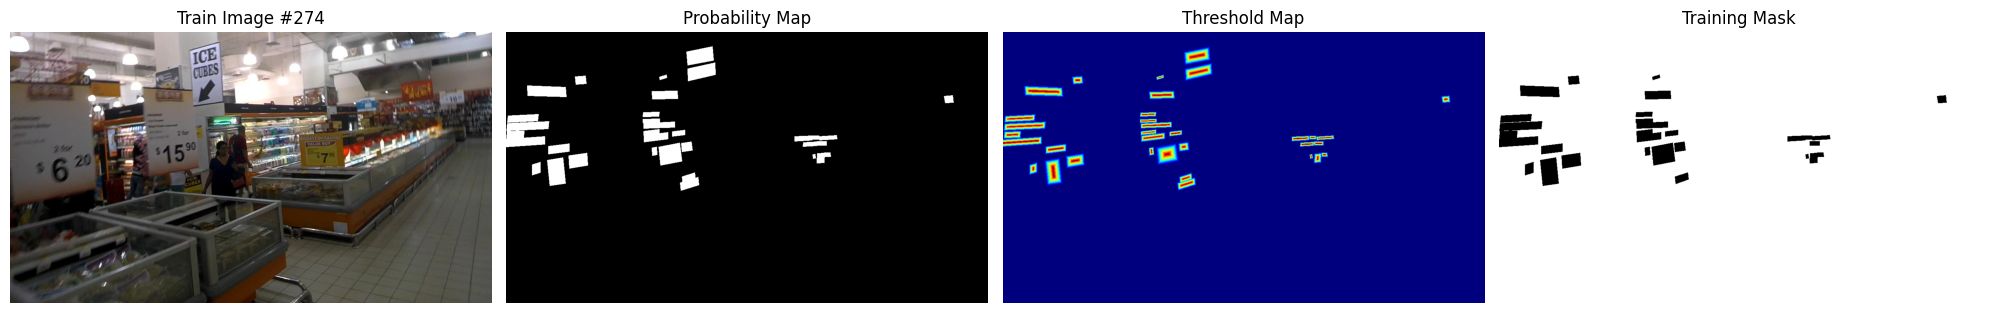

Image: torch.Size([3, 720, 1280])
Probability Map: torch.Size([720, 1280])
Threshold Map: torch.Size([720, 1280])
Training Mask: torch.Size([720, 1280])


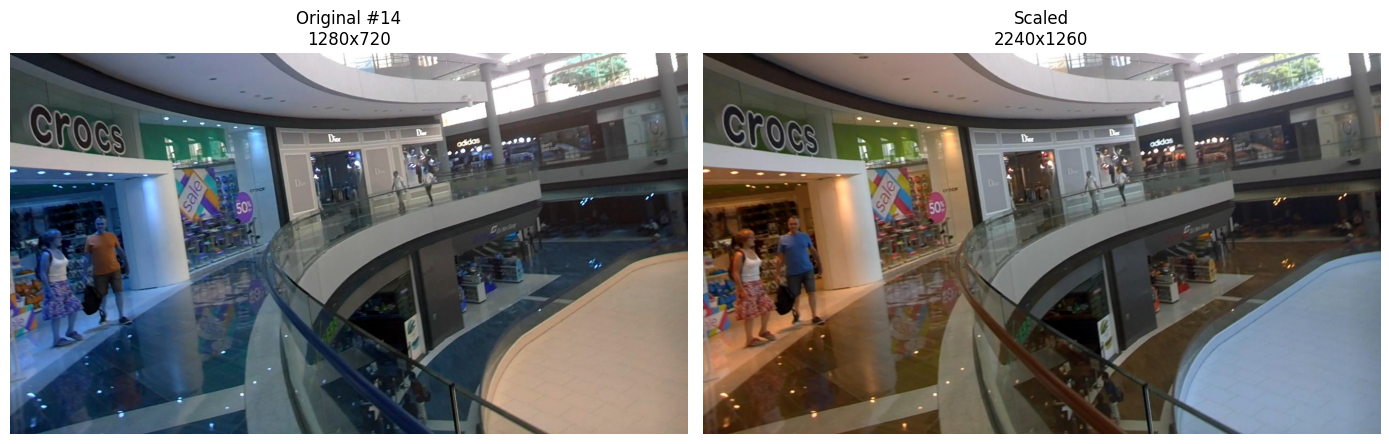

Original: (720, 1280, 3)
Scaled Tensor: torch.Size([3, 1260, 2240])


In [77]:
show_random_sample(train_dataset,dbnet=True)
show_random_sample(test_dataset,is_train = False)

In [78]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on: {device}")


batch_size = 4 
num_epochs = 30
learning_rate = 1e-4


full_train_dataset = DBNetLoader() 


total_size = len(full_train_dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size


train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

print(f"Dataset Split -> Total: {total_size} | Train: {train_size} | Val: {val_size}")


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, drop_last=False) 


model = DBNet(pretrained_backbone=True).to(device)
criterion = DBLoss(alpha=1.0, beta=10.0)
optimizer = Adam(model.parameters(), lr=learning_rate)


test_dataset = IC15TestLoader(long_size=2240)
post_processor = DBPostProcess(prob_threshold=0.3, unclip_ratio=1.5, min_area=16)

Executing on: cpu
Dataset Split -> Total: 1000 | Train: 800 | Val: 200


In [79]:
import numpy as np
import torch

class EarlyStopping:
    def __init__(self, patience=5, delta=0.001, path='dbnet_best_weights.pth'):
        """
        Args:
            patience (int): How many epochs to wait after last time validation loss improved.
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
            path (str): Path for the checkpoint to be saved to.
        """
        self.patience = patience
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        """Saves model when validation loss decreases."""
        print(f"Validation loss decreased ({self.val_loss_min:.4f} --> {val_loss:.4f}). Saving best model...")
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [80]:
# # ... [Assuming model, optimizer, criterion, train_loader, val_loader are initialized] ...

# # 1. Initialize Early Stopping
# # Patience of 7 means it will wait for 7 epochs of no improvement before killing the run.
# early_stopping = EarlyStopping(patience=7, delta=0.005, path='dbnet_icdar_best.pth')

# print("Starting DBNet Training with Train/Val Split & Early Stopping...")

# for epoch in range(num_epochs):
#     # ==========================================
#     #               TRAINING LOOP
#     # ==========================================
#     model.train()
#     epoch_loss = 0.0
    
#     for batch_idx, batch in enumerate(train_loader):
#         # [Your existing training logic unpacking and forward pass...]
#         images, gt_prob, gt_thresh, training_mask = batch
#         images = images.to(device)
#         gt_prob = gt_prob.unsqueeze(1).to(device)
#         gt_thresh = gt_thresh.unsqueeze(1).to(device)
#         training_mask = training_mask.unsqueeze(1).to(device)
        
#         thresh_mask = (gt_thresh > 0).float()
#         labels = {'gt_prob': gt_prob, 'gt_thresh': gt_thresh, 'thresh_mask': thresh_mask, 'training_mask': training_mask}
        
#         optimizer.zero_grad()
#         preds = model(images)
#         loss, metrics = criterion(preds, labels)
        
#         loss.backward()
#         optimizer.step()
        
#         epoch_loss += loss.item()
#         if batch_idx % 50 == 0:
#             print(f"Epoch [{epoch+1}/{num_epochs}] Train Batch [{batch_idx}/{len(train_loader)}] Loss: {loss.item():.4f}")
            
#     avg_train_loss = epoch_loss / len(train_loader)

#     # ==========================================
#     #              VALIDATION LOOP
#     # ==========================================
#     model.eval()
#     val_loss = 0.0
    
#     with torch.no_grad():
#         for val_batch in val_loader:
#             # [Your existing validation logic...]
#             v_images, v_gt_prob, v_gt_thresh, v_training_mask = val_batch
#             v_images = v_images.to(device)
#             v_gt_prob = v_gt_prob.unsqueeze(1).to(device)
#             v_gt_thresh = v_gt_thresh.unsqueeze(1).to(device)
#             v_training_mask = v_training_mask.unsqueeze(1).to(device)
            
#             v_thresh_mask = (v_gt_thresh > 0).float()
#             v_labels = {'gt_prob': v_gt_prob, 'gt_thresh': v_gt_thresh, 'thresh_mask': v_thresh_mask, 'training_mask': v_training_mask}
            
#             v_preds = model(v_images)
#             v_batch_loss, _ = criterion(v_preds, v_labels)
#             val_loss += v_batch_loss.item()
            
#     avg_val_loss = val_loss / len(val_loader)
    
#     # --- Epoch Summary ---
#     print(f"\n--- Epoch {epoch+1} Completed ---")
#     print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
#     # ==========================================
#     #           EARLY STOPPING CHECK
#     # ==========================================
#     # Pass the validation loss and the current model to the early stopping tracker
#     early_stopping(avg_val_loss, model)
    
#     if early_stopping.early_stop:
#         print("Early stopping triggered! Training halted to prevent overfitting.")
#         break # Breaks out of the main epoch loop
#     print("-" * 50)
    

#     print("Generating Visual Prediction on Test Set...")
#     visualize_random_val_prediction(model, test_dataset, post_processor, device)
#     print("=" * 50)

# # Once the loop ends (either naturally or via early stopping), load the best weights back in
# print("Training session finished. Loading the best model weights...")
# model.load_state_dict(torch.load('dbnet_icdar_best.pth'))

Loading model weights...
Running forward pass...
Decoding bounding boxes...


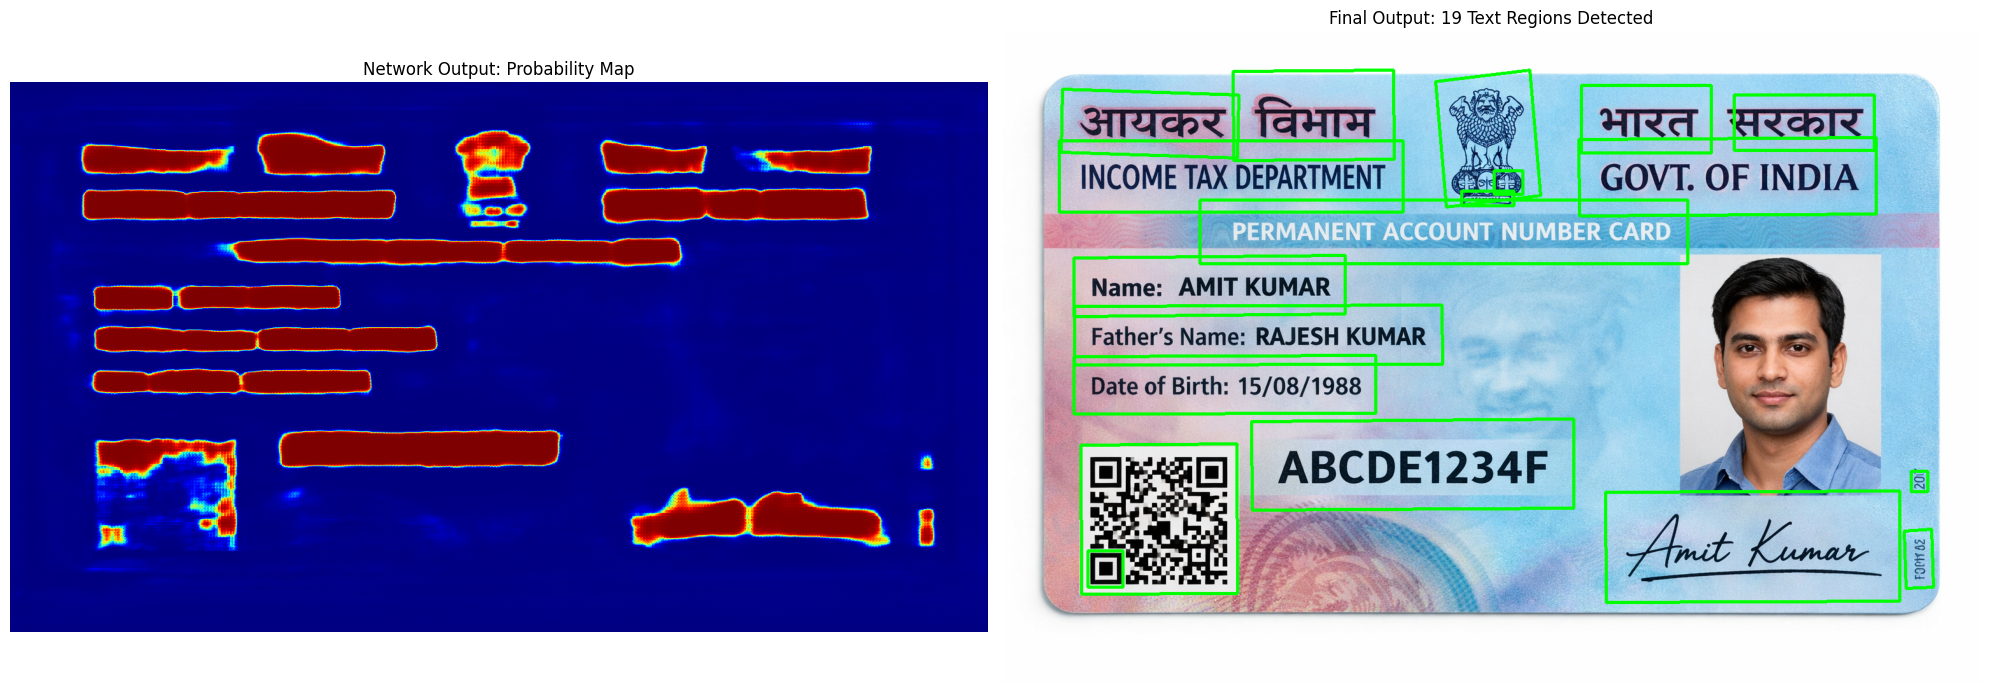

In [82]:
class DBPostProcess:
    def __init__(self, prob_threshold=0.3, unclip_ratio=1.5, min_area=16):
        self.prob_threshold = prob_threshold
        self.unclip_ratio = unclip_ratio
        self.min_area = min_area

    def __call__(self, prob_map, orig_shape, target_shape):
        prob_map = prob_map.squeeze().cpu().numpy()
        segmentation = prob_map > self.prob_threshold
        mask = (segmentation * 255).astype(np.uint8)
        
        contours, _ = cv2.findContours(mask, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
        
        boxes = []
        for contour in contours:
            poly = cv2.approxPolyDP(contour, epsilon=0.005 * cv2.arcLength(contour, True), closed=True)
            if len(poly) < 4:
                rect = cv2.minAreaRect(contour)
                poly = cv2.boxPoints(rect)
            else:
                poly = poly.reshape(-1, 2)
                
            polygon_shape = Polygon(poly)
            if polygon_shape.area < self.min_area:
                continue
                
            distance = polygon_shape.area * self.unclip_ratio / (polygon_shape.length + 1e-5)
            offset = pyclipper.PyclipperOffset()
            offset.AddPath(poly.astype(np.int32), pyclipper.JT_ROUND, pyclipper.ET_CLOSEDPOLYGON)
            expanded = offset.Execute(distance)
            
            if len(expanded) == 0:
                continue
            
            expanded_poly = np.array(expanded[0])
            rect = cv2.minAreaRect(expanded_poly)
            box = cv2.boxPoints(rect)
            
            # Scale coordinates back to the original image dimensions
            scale_x = orig_shape[1] / target_shape[1]
            scale_y = orig_shape[0] / target_shape[0]
            
            box[:, 0] = np.clip(box[:, 0] * scale_x, 0, orig_shape[1] - 1)
            box[:, 1] = np.clip(box[:, 1] * scale_y, 0, orig_shape[0] - 1)
            
            box = self.order_points_clockwise(box)
            boxes.append(box.astype(np.int32))
            
        return boxes

    def order_points_clockwise(self, pts):
        rect = np.zeros((4, 2), dtype=np.float32)
        s = pts.sum(axis=1)
        rect[0] = pts[np.argmin(s)]
        rect[2] = pts[np.argmax(s)]
        diff = np.diff(pts, axis=1)
        rect[1] = pts[np.argmin(diff)]
        rect[3] = pts[np.argmax(diff)]
        return rect

# --- 2. The Inference Function ---
def predict_image(image_path, model_path, target_size=(1280, 720)):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 1. Load the Model and Weights
    print("Loading model weights...")
    model = DBNet(pretrained_backbone=False).to(device) # False because we are loading our own weights now
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval() # CRITICAL: Switch to inference mode
    
    post_processor = DBPostProcess(prob_threshold=0.3, unclip_ratio=1.2)
    
    # 2. Read and Preprocess the Image
    orig_image = cv2.imread(image_path)
    if orig_image is None:
        raise FileNotFoundError(f"Could not load image at {image_path}")
        
    orig_image = cv2.cvtColor(orig_image, cv2.COLOR_BGR2RGB)
    orig_shape = orig_image.shape[:2] # (H, W)
    
    # Resize to the standard scale used during training
    resized_image = cv2.resize(orig_image, (target_size[0], target_size[1]))
    
    # ImageNet Normalization
    img_tensor = torch.from_numpy(resized_image).float().permute(2, 0, 1) / 255.0
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_tensor = (img_tensor - mean) / std
    
    # Add Batch Dimension -> [1, 3, H, W]
    img_tensor = img_tensor.unsqueeze(0).to(device)
    
    # 3. Forward Pass
    print("Running forward pass...")
    with torch.no_grad():
        outputs = model(img_tensor)
        prob_map = outputs['prob_map']
        
    # 4. Extract Bounding Boxes
    print("Decoding bounding boxes...")
    boxes = post_processor(prob_map, orig_shape, (target_size[1], target_size[0]))
    
    # 5. Draw Boxes and Visualize
    vis_image = orig_image.copy()
    for box in boxes:
        # Draw a bright green polygon with a thickness of 3
        cv2.polylines(vis_image, [box.astype(int)], isClosed=True, color=(0, 255, 0), thickness=3)
        
    # Show the raw probability map next to the final image for debugging
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    axes[0].imshow(prob_map.squeeze().cpu().numpy(), cmap='jet')
    axes[0].set_title("Network Output: Probability Map")
    axes[0].axis('off')
    
    axes[1].imshow(vis_image)
    axes[1].set_title(f"Final Output: {len(boxes)} Text Regions Detected")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return boxes

# --- 3. Execution ---
if __name__ == "__main__":
    # Replace these paths with your actual files
    TEST_IMAGE_PATH = "/Users/pashantraj/Desktop/jmr/pan.png" 
    WEIGHTS_PATH = "/Users/pashantraj/Desktop/Repos/Computer_vision/ICDAR15/dbnet_icdar_best.pth" 
    
    # Using 1280 (W) x 720 (H) as it matches the aspect ratio of your training prints
    predicted_boxes = predict_image(TEST_IMAGE_PATH, WEIGHTS_PATH, target_size=(1280, 720))